# DriftGuard — Repository-Disjoint Validation

This notebook evaluates all trained model families on a repository that was
not used for model training:

- TF-IDF text baseline
- Structured Extra Trees model
- CodeBERTa Transformer

The repository-disjoint validation partition is used to:

- Measure cross-repository generalization
- Compare model families
- Analyze safety-critical errors
- Analyze disagreements between models
- Select the primary model used by the hybrid engine
- Build a prioritized manual-review queue

The final test partition remains sealed. Its file hash is recorded, but its
contents are not loaded or evaluated in this notebook.

Validation labels remain weak labels and must not be described as manually
verified ground truth.

In [1]:
import os
import sys
import ast
import json
import math
import time
import gzip
import hashlib
import warnings
from pathlib import Path
from datetime import datetime, timezone
from collections import Counter

import joblib
import nbformat
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    log_loss,
    confusion_matrix,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
)

from tqdm.auto import tqdm


print("=" * 72)
print("DRIFTGUARD — REPOSITORY-DISJOINT VALIDATION")
print("=" * 72)

current_directory = Path.cwd().resolve()

if current_directory.name.lower() == "notebooks":
    PROJECT_ROOT = current_directory.parent
else:
    PROJECT_ROOT = current_directory

NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
CLEAN_DATA_DIR = PROJECT_ROOT / "data" / "clean"
CONFIGS_DIR = PROJECT_ROOT / "configs"

BASELINE_MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / "baselines"
    / "best_baseline_model.joblib"
)

STRUCTURED_MODEL_PATH = (
    PROJECT_ROOT
    / "models"
    / "structured"
    / "best_structured_model.joblib"
)

TRANSFORMER_MODEL_DIR = (
    PROJECT_ROOT
    / "models"
    / "transformer"
    / "best_codeberta_model"
)

OUTPUTS_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "repository_disjoint_evaluation"
)

TABLES_DIR = OUTPUTS_DIR / "tables"
FIGURES_DIR = OUTPUTS_DIR / "figures"
PREDICTIONS_DIR = OUTPUTS_DIR / "predictions"
REVIEW_DIR = OUTPUTS_DIR / "manual_review"
MANIFESTS_DIR = OUTPUTS_DIR / "manifests"

for directory in [
    OUTPUTS_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    PREDICTIONS_DIR,
    REVIEW_DIR,
    MANIFESTS_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

warnings.filterwarnings("default")

print("Python executable       :", sys.executable)
print("Project root            :", PROJECT_ROOT)
print("Baseline model          :", BASELINE_MODEL_PATH)
print("Structured model        :", STRUCTURED_MODEL_PATH)
print("Transformer model       :", TRANSFORMER_MODEL_DIR)
print("Evaluation output folder:", OUTPUTS_DIR)

DRIFTGUARD — REPOSITORY-DISJOINT VALIDATION
Python executable       : C:\Users\Lenovo\anaconda3\envs\driftguard\python.exe
Project root            : C:\Users\Lenovo\Desktop\DriftGuard
Baseline model          : C:\Users\Lenovo\Desktop\DriftGuard\models\baselines\best_baseline_model.joblib
Structured model        : C:\Users\Lenovo\Desktop\DriftGuard\models\structured\best_structured_model.joblib
Transformer model       : C:\Users\Lenovo\Desktop\DriftGuard\models\transformer\best_codeberta_model
Evaluation output folder: C:\Users\Lenovo\Desktop\DriftGuard\outputs\repository_disjoint_evaluation


In [26]:
import re

In [2]:
REPOSITORY_EVALUATION_SETTINGS = {
    "random_seed": 42,

    "class_order": [
        "benign",
        "low",
        "medium",
        "high",
        "critical",
    ],

    "expected_validation_records": 7_628,
    "expected_final_test_records": 68_749,

    "transformer_inference_batch_size": 8,
    "transformer_maximum_sequence_length": 256,

    "review_queue_size": 500,

    "selection_metrics": [
        "macro_f1",
        "critical_recall",
        "high_critical_recall",
        "macro_pr_auc",
        "balanced_accuracy",
    ],
}

CLASS_ORDER = REPOSITORY_EVALUATION_SETTINGS[
    "class_order"
]

CLASS_TO_ID = {
    class_name: class_index
    for class_index, class_name
    in enumerate(CLASS_ORDER)
}

ID_TO_CLASS = {
    class_index: class_name
    for class_name, class_index
    in CLASS_TO_ID.items()
}

settings_path = (
    CONFIGS_DIR
    / "repository_disjoint_evaluation_settings.json"
)

with settings_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        REPOSITORY_EVALUATION_SETTINGS,
        file,
        indent=2,
    )

print(
    json.dumps(
        REPOSITORY_EVALUATION_SETTINGS,
        indent=2,
    )
)

{
  "random_seed": 42,
  "class_order": [
    "benign",
    "low",
    "medium",
    "high",
    "critical"
  ],
  "expected_validation_records": 7628,
  "expected_final_test_records": 68749,
  "transformer_inference_batch_size": 8,
  "transformer_maximum_sequence_length": 256,
  "review_queue_size": 500,
  "selection_metrics": [
    "macro_f1",
    "critical_recall",
    "high_critical_recall",
    "macro_pr_auc",
    "balanced_accuracy"
  ]
}


In [3]:
def restore_literal_assignments(
    notebook_path,
    namespace,
):
    notebook = nbformat.read(
        notebook_path,
        as_version=4,
    )

    restored_names = []

    for cell in notebook.cells:
        if cell.cell_type != "code":
            continue

        try:
            syntax_tree = ast.parse(
                cell.source
            )
        except SyntaxError:
            continue

        for node in syntax_tree.body:
            target_names = []
            value_node = None

            if isinstance(
                node,
                ast.Assign,
            ):
                value_node = node.value

                for target in node.targets:
                    if isinstance(
                        target,
                        ast.Name,
                    ):
                        target_names.append(
                            target.id
                        )

            elif isinstance(
                node,
                ast.AnnAssign,
            ):
                value_node = node.value

                if isinstance(
                    node.target,
                    ast.Name,
                ):
                    target_names.append(
                        node.target.id
                    )

            if (
                not target_names
                or value_node is None
            ):
                continue

            try:
                literal_value = ast.literal_eval(
                    value_node
                )
            except Exception:
                continue

            for target_name in target_names:
                namespace[target_name] = (
                    literal_value
                )

                restored_names.append(
                    target_name
                )

    return sorted(
        set(restored_names)
    )


previous_notebooks = [
    NOTEBOOKS_DIR
    / "07_train_baseline_models.ipynb",

    NOTEBOOKS_DIR
    / "08_train_structured_ml_models.ipynb",

    NOTEBOOKS_DIR
    / "09_train_nlp_transformer.ipynb",
]

restored_literal_names = []

for notebook_path in previous_notebooks:
    if not notebook_path.exists():
        raise FileNotFoundError(
            f"Missing required notebook:\n{notebook_path}"
        )

    restored_literal_names.extend(
        restore_literal_assignments(
            notebook_path=notebook_path,
            namespace=globals(),
        )
    )

print(
    "Static constants restored:",
    len(
        set(restored_literal_names)
    ),
)

Static constants restored: 38


In [4]:
def load_json_if_present(
    candidate_paths,
):
    for candidate_path in candidate_paths:
        if candidate_path.exists():
            with candidate_path.open(
                "r",
                encoding="utf-8",
            ) as file:
                return (
                    json.load(file),
                    candidate_path,
                )

    return {}, None


baseline_configuration_candidates = list(
    CONFIGS_DIR.glob(
        "*baseline*settings*.json"
    )
)

(
    BASELINE_SETTINGS,
    baseline_settings_path,
) = load_json_if_present(
    baseline_configuration_candidates
)

structured_settings_path = (
    CONFIGS_DIR
    / "structured_model_training_settings.json"
)

transformer_settings_path = (
    CONFIGS_DIR
    / "transformer_training_settings.json"
)

(
    STRUCTURED_SETTINGS,
    loaded_structured_settings_path,
) = load_json_if_present(
    [
        structured_settings_path,
    ]
)

(
    TRANSFORMER_SETTINGS,
    loaded_transformer_settings_path,
) = load_json_if_present(
    [
        transformer_settings_path,
    ]
)

if not STRUCTURED_SETTINGS:
    raise FileNotFoundError(
        "Structured training settings were not found."
    )

if not TRANSFORMER_SETTINGS:
    raise FileNotFoundError(
        "Transformer training settings were not found."
    )

TRANSFORMER_RAW_FEATURE_COLUMNS = [
    "field_path",
    "old_value",
    "new_value",
    "configuration_type",
    "operation",
    "parser_mode",
    "file_path",
    "commit_message",
]

MAXIMUM_SEQUENCE_LENGTH = int(
    TRANSFORMER_SETTINGS.get(
        "maximum_sequence_length",
        256,
    )
)

print(
    "Baseline settings:",
    baseline_settings_path,
)

print(
    "Structured settings:",
    loaded_structured_settings_path,
)

print(
    "Transformer settings:",
    loaded_transformer_settings_path,
)

print(
    "Maximum Transformer length:",
    MAXIMUM_SEQUENCE_LENGTH,
)

Baseline settings: C:\Users\Lenovo\Desktop\DriftGuard\configs\baseline_model_training_settings.json
Structured settings: C:\Users\Lenovo\Desktop\DriftGuard\configs\structured_model_training_settings.json
Transformer settings: C:\Users\Lenovo\Desktop\DriftGuard\configs\transformer_training_settings.json
Maximum Transformer length: 256


In [6]:
def restore_function_definitions(
    notebook_path,
    namespace,
):
    notebook = nbformat.read(
        notebook_path,
        as_version=4,
    )

    restored_functions = []
    failed_functions = []

    for cell in notebook.cells:
        if cell.cell_type != "code":
            continue

        try:
            syntax_tree = ast.parse(
                cell.source
            )
        except SyntaxError:
            continue

        for node in syntax_tree.body:
            if not isinstance(
                node,
                (
                    ast.FunctionDef,
                    ast.AsyncFunctionDef,
                ),
            ):
                continue

            function_module = ast.Module(
                body=[node],
                type_ignores=[],
            )

            ast.fix_missing_locations(
                function_module
            )

            try:
                compiled_function = compile(
                    function_module,
                    filename=str(
                        notebook_path
                    ),
                    mode="exec",
                )

                exec(
                    compiled_function,
                    namespace,
                )

                restored_functions.append(
                    node.name
                )

            except Exception as error:
                failed_functions.append(
                    {
                        "function": node.name,
                        "error": str(error),
                    }
                )

    return (
        sorted(
            set(restored_functions)
        ),
        failed_functions,
    )


restored_function_names = []
function_restore_errors = []

for notebook_path in previous_notebooks:
    (
        notebook_functions,
        notebook_errors,
    ) = restore_function_definitions(
        notebook_path=notebook_path,
        namespace=globals(),
    )

    restored_function_names.extend(
        notebook_functions
    )

    function_restore_errors.extend(
        notebook_errors
    )

required_preprocessing_functions = [
    "engineer_structured_features",
    "build_transformer_text",
]

missing_preprocessing_functions = [
    function_name
    for function_name
    in required_preprocessing_functions
    if function_name not in globals()
]

print(
    "Functions restored:",
    len(
        set(restored_function_names)
    ),
)

print(
    "Function restoration warnings:",
    len(
        function_restore_errors
    ),
)

if missing_preprocessing_functions:
    raise RuntimeError(
        "Required preprocessing functions were not restored:\n"
        + "\n".join(
            missing_preprocessing_functions
        )
    )

print(
    "Required preprocessing functions: PASSED"
)

Functions restored: 32
Function restoration warnings: 0
Required preprocessing functions: PASSED


In [7]:
def count_compressed_csv_rows(
    file_path,
):
    with gzip.open(
        file_path,
        mode="rt",
        encoding="utf-8",
        errors="replace",
    ) as file:
        line_count = sum(
            1
            for _ in file
        )

    return max(
        line_count - 1,
        0,
    )


def locate_partition_file(
    partition_keyword,
    expected_records,
):
    candidates = [
        file_path
        for file_path
        in CLEAN_DATA_DIR.glob(
            "*.csv.gz"
        )
        if partition_keyword.lower()
        in file_path.name.lower()
    ]

    if not candidates:
        candidates = list(
            CLEAN_DATA_DIR.glob(
                "*.csv.gz"
            )
        )

    candidate_records = []

    for file_path in candidates:
        try:
            record_count = (
                count_compressed_csv_rows(
                    file_path
                )
            )
        except Exception:
            continue

        score = 0

        filename_lower = (
            file_path.name.lower()
        )

        if partition_keyword in filename_lower:
            score += 10

        if record_count == expected_records:
            score += 100

        if (
            partition_keyword == "validation"
            and "review" in filename_lower
        ):
            score += 5

        if (
            partition_keyword == "test"
            and "final" in filename_lower
        ):
            score += 5

        candidate_records.append(
            {
                "path": file_path,
                "records": record_count,
                "score": score,
            }
        )

    if not candidate_records:
        raise FileNotFoundError(
            f"No CSV files were found for {partition_keyword}."
        )

    candidate_table = pd.DataFrame(
        candidate_records
    ).sort_values(
        [
            "score",
            "records",
        ],
        ascending=[
            False,
            False,
        ],
    )

    selected_path = (
        candidate_table.iloc[0][
            "path"
        ]
    )

    return (
        Path(selected_path),
        candidate_table,
    )


(
    validation_data_path,
    validation_candidates,
) = locate_partition_file(
    partition_keyword="validation",
    expected_records=(
        REPOSITORY_EVALUATION_SETTINGS[
            "expected_validation_records"
        ]
    ),
)

(
    sealed_test_data_path,
    test_candidates,
) = locate_partition_file(
    partition_keyword="test",
    expected_records=(
        REPOSITORY_EVALUATION_SETTINGS[
            "expected_final_test_records"
        ]
    ),
)

print(
    "Selected validation file:",
    validation_data_path.name,
)

print(
    "Selected sealed test file:",
    sealed_test_data_path.name,
)

display(
    validation_candidates.head(10)
)

display(
    test_candidates.head(10)
)

Selected validation file: validation_review_only.csv.gz
Selected sealed test file: test_final_evaluation_only.csv.gz


,path,records,score
0,C:\Users\Lenovo\Desktop\DriftGuard\data\clean\...,54783,15


,path,records,score
0,C:\Users\Lenovo\Desktop\DriftGuard\data\clean\...,643406,15


In [8]:
def calculate_file_sha256(
    file_path,
    chunk_size=1024 * 1024,
):
    digest = hashlib.sha256()

    with file_path.open(
        "rb"
    ) as file:
        while True:
            chunk = file.read(
                chunk_size
            )

            if not chunk:
                break

            digest.update(
                chunk
            )

    return digest.hexdigest()


sealed_test_sha256 = (
    calculate_file_sha256(
        sealed_test_data_path
    )
)

sealed_test_manifest = {
    "created_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),

    "status": "SEALED_NOT_LOADED",

    "file_path": str(
        sealed_test_data_path
    ),

    "file_name": (
        sealed_test_data_path.name
    ),

    "size_bytes": int(
        sealed_test_data_path.stat().st_size
    ),

    "sha256": sealed_test_sha256,

    "expected_records": (
        REPOSITORY_EVALUATION_SETTINGS[
            "expected_final_test_records"
        ]
    ),

    "intended_use": (
        "One-time final evaluation after the "
        "hybrid engine and drift scoring are frozen."
    ),
}

sealed_test_manifest_path = (
    MANIFESTS_DIR
    / "sealed_final_test_manifest.json"
)

with sealed_test_manifest_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        sealed_test_manifest,
        file,
        indent=2,
    )

print("Final test status : SEALED")
print("Final test SHA-256:", sealed_test_sha256)
print("Manifest saved    :", sealed_test_manifest_path)

Final test status : SEALED
Final test SHA-256: cff0f85db740a195366fb81cbad26ba34859f40fe12bf8695b263d1cdedb9b67
Manifest saved    : C:\Users\Lenovo\Desktop\DriftGuard\outputs\repository_disjoint_evaluation\manifests\sealed_final_test_manifest.json


In [9]:
model_training_path = (
    CLEAN_DATA_DIR
    / "train_temporal_model_train.csv.gz"
)

temporal_development_path = (
    CLEAN_DATA_DIR
    / "train_temporal_development.csv.gz"
)

if not model_training_path.exists():
    raise FileNotFoundError(
        model_training_path
    )

if not temporal_development_path.exists():
    raise FileNotFoundError(
        temporal_development_path
    )

training_reference_data = pd.concat(
    [
        pd.read_csv(
            model_training_path,
            compression="gzip",
            low_memory=False,
        ),

        pd.read_csv(
            temporal_development_path,
            compression="gzip",
            low_memory=False,
        ),
    ],
    ignore_index=True,
)

validation_data = pd.read_csv(
    validation_data_path,
    compression="gzip",
    low_memory=False,
)

print(
    "Combined training-reference records:",
    f"{len(training_reference_data):,}",
)

print(
    "Repository-disjoint validation records:",
    f"{len(validation_data):,}",
)

Combined training-reference records: 9,576
Repository-disjoint validation records: 7,628


In [10]:
LABEL_COLUMN_CANDIDATES = [
    "training_target",
    "weak_label",
    "risk_label",
    "label",
]


def resolve_evaluation_label_column(
    dataframe,
):
    for candidate_column in (
        LABEL_COLUMN_CANDIDATES
    ):
        if candidate_column not in dataframe.columns:
            continue

        normalized_values = (
            dataframe[
                candidate_column
            ]
            .fillna("")
            .astype(str)
            .str.strip()
            .str.lower()
        )

        valid_count = int(
            normalized_values.isin(
                CLASS_ORDER
            ).sum()
        )

        if valid_count > 0:
            return candidate_column

    raise ValueError(
        "No usable evaluation-label column was found."
    )


validation_label_column = (
    resolve_evaluation_label_column(
        validation_data
    )
)

validation_data[
    "evaluation_label"
] = (
    validation_data[
        validation_label_column
    ]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.lower()
)

validation_labeled_mask = (
    validation_data[
        "evaluation_label"
    ].isin(
        CLASS_ORDER
    )
)

validation_labeled_data = (
    validation_data[
        validation_labeled_mask
    ]
    .copy()
)

print(
    "Resolved label column:",
    validation_label_column,
)

print(
    "Validation total records:",
    f"{len(validation_data):,}",
)

print(
    "Validation labeled records:",
    f"{len(validation_labeled_data):,}",
)

print(
    "Validation excluded/unlabeled:",
    f"{(~validation_labeled_mask).sum():,}",
)

display(
    validation_labeled_data[
        "evaluation_label"
    ]
    .value_counts()
    .reindex(
        CLASS_ORDER,
        fill_value=0,
    )
    .rename_axis("class")
    .reset_index(name="records")
)

Resolved label column: weak_label
Validation total records: 7,628
Validation labeled records: 7,040
Validation excluded/unlabeled: 588


,class,records
0,benign,4848
1,low,2084
2,medium,25
3,high,57
4,critical,26


In [11]:
training_repositories = set(
    training_reference_data[
        "repository"
    ]
    .dropna()
    .astype(str)
    .unique()
)

validation_repositories = set(
    validation_data[
        "repository"
    ]
    .dropna()
    .astype(str)
    .unique()
)

repository_overlap = (
    training_repositories
    & validation_repositories
)

training_commit_keys = set(
    zip(
        training_reference_data[
            "repository"
        ].astype(str),

        training_reference_data[
            "commit_hash"
        ].astype(str),
    )
)

validation_commit_keys = set(
    zip(
        validation_data[
            "repository"
        ].astype(str),

        validation_data[
            "commit_hash"
        ].astype(str),
    )
)

commit_overlap = (
    training_commit_keys
    & validation_commit_keys
)

signature_overlap_count = None

if (
    "change_signature_sha256"
    in training_reference_data.columns
    and "change_signature_sha256"
    in validation_data.columns
):
    training_signatures = set(
        training_reference_data[
            "change_signature_sha256"
        ]
        .dropna()
        .astype(str)
    )

    validation_signatures = set(
        validation_data[
            "change_signature_sha256"
        ]
        .dropna()
        .astype(str)
    )

    signature_overlap_count = len(
        training_signatures
        & validation_signatures
    )

print(
    "Training repositories:",
    sorted(
        training_repositories
    ),
)

print(
    "Validation repositories:",
    sorted(
        validation_repositories
    ),
)

print(
    "Repository overlap:",
    len(
        repository_overlap
    ),
)

print(
    "Commit overlap:",
    len(
        commit_overlap
    ),
)

print(
    "Change-signature overlap:",
    signature_overlap_count,
)

if repository_overlap:
    raise ValueError(
        "Repository leakage was detected."
    )

if commit_overlap:
    raise ValueError(
        "Commit leakage was detected."
    )

if (
    signature_overlap_count is not None
    and signature_overlap_count != 0
):
    raise ValueError(
        "Change-signature leakage was detected."
    )

print(
    "Repository-disjoint leakage checks: PASSED"
)

Training repositories: ['kube_prometheus', 'microservices_demo', 'terraform_aws_vpc']
Validation repositories: ['kubernetes_examples']
Repository overlap: 0
Commit overlap: 0
Change-signature overlap: 0
Repository-disjoint leakage checks: PASSED


In [12]:
required_model_paths = {
    "text baseline":
        BASELINE_MODEL_PATH,

    "structured model":
        STRUCTURED_MODEL_PATH,

    "Transformer model directory":
        TRANSFORMER_MODEL_DIR,
}

for model_name, model_path in (
    required_model_paths.items()
):
    if not model_path.exists():
        raise FileNotFoundError(
            f"Missing {model_name}:\n{model_path}"
        )

required_raw_columns = [
    "field_path",
    "old_value",
    "new_value",
    "configuration_type",
    "operation",
    "parser_mode",
    "file_path",
    "commit_message",
]

missing_validation_columns = sorted(
    set(
        required_raw_columns
        + [
            "repository",
            "commit_hash",
        ]
    )
    - set(validation_data.columns)
)

if missing_validation_columns:
    raise ValueError(
        "Validation data is missing columns:\n"
        + "\n".join(
            missing_validation_columns
        )
    )

print("Model and input validation: PASSED")

Model and input validation: PASSED


In [13]:
print("Loading text baseline...")

try:
    text_baseline_model = joblib.load(
        BASELINE_MODEL_PATH
    )
except Exception as error:
    print(
        "Text model loading failed:",
        type(error).__name__,
        str(error),
    )

    print(
        "\nThe functions restored from Notebook 07 were:"
    )

    print(
        sorted(
            set(restored_function_names)
        )
    )

    raise

print("Loading structured model...")

structured_model = joblib.load(
    STRUCTURED_MODEL_PATH
)

print(
    "Text baseline loaded:",
    type(text_baseline_model).__name__,
)

print(
    "Structured model loaded:",
    type(structured_model).__name__,
)

Loading text baseline...
Loading structured model...
Text baseline loaded: Pipeline
Structured model loaded: Pipeline


In [14]:
CUDA_AVAILABLE = torch.cuda.is_available()

DEVICE = torch.device(
    "cuda"
    if CUDA_AVAILABLE
    else "cpu"
)

transformer_tokenizer = (
    AutoTokenizer.from_pretrained(
        TRANSFORMER_MODEL_DIR,
        use_fast=True,
    )
)

transformer_model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        TRANSFORMER_MODEL_DIR
    )
)

transformer_model.to(
    DEVICE
)

transformer_model.eval()

print("CUDA available :", CUDA_AVAILABLE)
print("Inference device:", DEVICE)

if CUDA_AVAILABLE:
    print(
        "GPU:",
        torch.cuda.get_device_name(0),
    )

print(
    "Transformer labels:",
    transformer_model.config.id2label,
)

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

CUDA available : True
Inference device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Transformer labels: {0: 'benign', 1: 'low', 2: 'medium', 3: 'high', 4: 'critical'}


In [16]:
def get_classifier_classes(
    fitted_model,
):
    if hasattr(
        fitted_model,
        "classes_",
    ):
        return [
            str(class_name)
            for class_name
            in fitted_model.classes_
        ]

    if hasattr(
        fitted_model,
        "named_steps",
    ):
        classifier = (
            fitted_model.named_steps.get(
                "classifier"
            )
        )

        if (
            classifier is not None
            and hasattr(
                classifier,
                "classes_",
            )
        ):
            return [
                str(class_name)
                for class_name
                in classifier.classes_
            ]

    raise AttributeError(
        "Model classes could not be resolved."
    )


def align_score_matrix(
    score_matrix,
    model_classes,
    class_order,
):
    score_matrix = np.asarray(
        score_matrix
    )

    if score_matrix.ndim == 1:
        score_matrix = np.column_stack(
            [
                -score_matrix,
                score_matrix,
            ]
        )

    aligned_matrix = np.zeros(
        (
            score_matrix.shape[0],
            len(class_order),
        ),
        dtype=float,
    )

    for source_index, class_name in enumerate(
        model_classes
    ):
        if class_name not in class_order:
            continue

        target_index = class_order.index(
            class_name
        )

        aligned_matrix[
            :,
            target_index,
        ] = score_matrix[
            :,
            source_index,
        ]

    return aligned_matrix


def stable_softmax(
    score_matrix,
):
    score_matrix = np.asarray(
        score_matrix,
        dtype=float,
    )

    shifted_scores = (
        score_matrix
        - score_matrix.max(
            axis=1,
            keepdims=True,
        )
    )

    exponentials = np.exp(
        shifted_scores
    )

    denominator = exponentials.sum(
        axis=1,
        keepdims=True,
    )

    return exponentials / np.clip(
        denominator,
        1e-12,
        None,
    )

In [17]:
def run_text_baseline_inference(
    dataframe,
):
    start_time = time.perf_counter()

    predicted_labels = (
        text_baseline_model.predict(
            dataframe
        )
    )

    model_classes = (
        get_classifier_classes(
            text_baseline_model
        )
    )

    probability_matrix = None
    probability_kind = None

    if hasattr(
        text_baseline_model,
        "decision_function",
    ):
        raw_score_matrix = (
            text_baseline_model
            .decision_function(
                dataframe
            )
        )

        score_matrix = align_score_matrix(
            raw_score_matrix,
            model_classes,
            CLASS_ORDER,
        )

        probability_matrix = (
            stable_softmax(
                score_matrix
            )
        )

        probability_kind = (
            "decision_softmax_not_calibrated"
        )

    elif hasattr(
        text_baseline_model,
        "predict_proba",
    ):
        raw_probability_matrix = (
            text_baseline_model
            .predict_proba(
                dataframe
            )
        )

        probability_matrix = (
            align_score_matrix(
                raw_probability_matrix,
                model_classes,
                CLASS_ORDER,
            )
        )

        score_matrix = probability_matrix
        probability_kind = "probability"

    else:
        raise AttributeError(
            "Text model does not expose scores."
        )

    inference_seconds = (
        time.perf_counter()
        - start_time
    )

    return {
        "predicted_labels":
            np.asarray(
                predicted_labels,
                dtype=str,
            ),

        "score_matrix":
            score_matrix,

        "probability_matrix":
            probability_matrix,

        "probability_kind":
            probability_kind,

        "inference_seconds":
            inference_seconds,
    }

In [19]:
def run_structured_inference(
    dataframe,
):
    start_time = time.perf_counter()

    engineered_features = (
        engineer_structured_features(
            dataframe
        )
    )

    predicted_labels = (
        structured_model.predict(
            engineered_features
        )
    )

    model_classes = (
        get_classifier_classes(
            structured_model
        )
    )

    if not hasattr(
        structured_model,
        "predict_proba",
    ):
        raise AttributeError(
            "Structured model does not expose predict_proba."
        )

    raw_probability_matrix = (
        structured_model.predict_proba(
            engineered_features
        )
    )

    probability_matrix = (
        align_score_matrix(
            raw_probability_matrix,
            model_classes,
            CLASS_ORDER,
        )
    )

    row_sums = probability_matrix.sum(
        axis=1,
        keepdims=True,
    )

    probability_matrix = (
        probability_matrix
        / np.clip(
            row_sums,
            1e-12,
            None,
        )
    )

    inference_seconds = (
        time.perf_counter()
        - start_time
    )

    return {
        "predicted_labels":
            np.asarray(
                predicted_labels,
                dtype=str,
            ),

        "score_matrix":
            probability_matrix,

        "probability_matrix":
            probability_matrix,

        "probability_kind":
            "probability",

        "inference_seconds":
            inference_seconds,

        "engineered_feature_count":
            engineered_features.shape[1],
    }

In [20]:
def run_transformer_inference(
    dataframe,
    batch_size=8,
):
    transformer_text = (
        build_transformer_text(
            dataframe
        )
    )

    all_probability_batches = []

    start_time = time.perf_counter()

    for start_index in tqdm(
        range(
            0,
            len(transformer_text),
            batch_size,
        ),
        desc="Transformer validation inference",
        unit="batch",
    ):
        end_index = min(
            start_index + batch_size,
            len(transformer_text),
        )

        text_batch = (
            transformer_text.iloc[
                start_index:end_index
            ]
            .astype(str)
            .tolist()
        )

        tokenized_batch = (
            transformer_tokenizer(
                text_batch,
                truncation=True,
                max_length=(
                    MAXIMUM_SEQUENCE_LENGTH
                ),
                padding=True,
                return_tensors="pt",
            )
        )

        tokenized_batch = {
            key: value.to(
                DEVICE
            )
            for key, value
            in tokenized_batch.items()
        }

        with torch.inference_mode():
            if CUDA_AVAILABLE:
                with torch.autocast(
                    device_type="cuda",
                    dtype=torch.float16,
                ):
                    model_output = (
                        transformer_model(
                            **tokenized_batch
                        )
                    )
            else:
                model_output = (
                    transformer_model(
                        **tokenized_batch
                    )
                )

        probability_batch = (
            torch.softmax(
                model_output.logits,
                dim=1,
            )
            .detach()
            .cpu()
            .numpy()
        )

        all_probability_batches.append(
            probability_batch
        )

    probability_matrix = np.vstack(
        all_probability_batches
    )

    predicted_ids = np.argmax(
        probability_matrix,
        axis=1,
    )

    predicted_labels = np.asarray(
        [
            ID_TO_CLASS[
                int(predicted_id)
            ]
            for predicted_id
            in predicted_ids
        ],
        dtype=str,
    )

    inference_seconds = (
        time.perf_counter()
        - start_time
    )

    return {
        "predicted_labels":
            predicted_labels,

        "score_matrix":
            probability_matrix,

        "probability_matrix":
            probability_matrix,

        "probability_kind":
            "probability",

        "inference_seconds":
            inference_seconds,
    }

In [21]:
def calculate_binary_metrics(
    true_labels,
    predicted_labels,
    positive_labels,
):
    true_binary = np.isin(
        true_labels,
        positive_labels,
    ).astype(int)

    predicted_binary = np.isin(
        predicted_labels,
        positive_labels,
    ).astype(int)

    return {
        "precision": float(
            precision_score(
                true_binary,
                predicted_binary,
                zero_division=0,
            )
        ),

        "recall": float(
            recall_score(
                true_binary,
                predicted_binary,
                zero_division=0,
            )
        ),

        "f1": float(
            f1_score(
                true_binary,
                predicted_binary,
                zero_division=0,
            )
        ),
    }


def calculate_macro_pr_auc(
    true_labels,
    score_matrix,
):
    average_precision_values = []

    for class_index, class_name in enumerate(
        CLASS_ORDER
    ):
        binary_target = (
            np.asarray(
                true_labels
            )
            == class_name
        ).astype(int)

        if (
            binary_target.sum() == 0
            or binary_target.sum()
            == len(binary_target)
        ):
            continue

        average_precision_values.append(
            average_precision_score(
                binary_target,
                score_matrix[
                    :,
                    class_index,
                ],
            )
        )

    if not average_precision_values:
        return np.nan

    return float(
        np.mean(
            average_precision_values
        )
    )


def calculate_model_metrics(
    model_name,
    model_output,
    labeled_mask,
    true_labels,
):
    predicted_labels = (
        model_output[
            "predicted_labels"
        ][labeled_mask]
    )

    score_matrix = (
        model_output[
            "score_matrix"
        ][labeled_mask]
    )

    probability_matrix = (
        model_output[
            "probability_matrix"
        ][labeled_mask]
    )

    critical_metrics = (
        calculate_binary_metrics(
            true_labels=true_labels,
            predicted_labels=(
                predicted_labels
            ),
            positive_labels=[
                "critical",
            ],
        )
    )

    high_critical_metrics = (
        calculate_binary_metrics(
            true_labels=true_labels,
            predicted_labels=(
                predicted_labels
            ),
            positive_labels=[
                "high",
                "critical",
            ],
        )
    )

    metrics = {
        "model": model_name,

        "records": len(
            true_labels
        ),

        "accuracy": float(
            accuracy_score(
                true_labels,
                predicted_labels,
            )
        ),

        "balanced_accuracy": float(
            balanced_accuracy_score(
                true_labels,
                predicted_labels,
            )
        ),

        "macro_precision": float(
            precision_score(
                true_labels,
                predicted_labels,
                labels=CLASS_ORDER,
                average="macro",
                zero_division=0,
            )
        ),

        "macro_recall": float(
            recall_score(
                true_labels,
                predicted_labels,
                labels=CLASS_ORDER,
                average="macro",
                zero_division=0,
            )
        ),

        "macro_f1": float(
            f1_score(
                true_labels,
                predicted_labels,
                labels=CLASS_ORDER,
                average="macro",
                zero_division=0,
            )
        ),

        "weighted_f1": float(
            f1_score(
                true_labels,
                predicted_labels,
                labels=CLASS_ORDER,
                average="weighted",
                zero_division=0,
            )
        ),

        "macro_pr_auc": (
            calculate_macro_pr_auc(
                true_labels,
                score_matrix,
            )
        ),

        "critical_precision":
            critical_metrics[
                "precision"
            ],

        "critical_recall":
            critical_metrics[
                "recall"
            ],

        "critical_f1":
            critical_metrics[
                "f1"
            ],

        "high_critical_precision":
            high_critical_metrics[
                "precision"
            ],

        "high_critical_recall":
            high_critical_metrics[
                "recall"
            ],

        "high_critical_f1":
            high_critical_metrics[
                "f1"
            ],

        "inference_seconds":
            model_output[
                "inference_seconds"
            ],

        "probability_kind":
            model_output[
                "probability_kind"
            ],
    }

    if (
        model_output[
            "probability_kind"
        ] == "probability"
    ):
        metrics["log_loss"] = float(
            log_loss(
                true_labels,
                probability_matrix,
                labels=CLASS_ORDER,
            )
        )
    else:
        metrics["log_loss"] = np.nan

    return metrics

In [24]:
import re

print("Regular-expression module loaded.")

Regular-expression module loaded.


In [25]:
print("=" * 72)
print("RUNNING REPOSITORY-DISJOINT VALIDATION")
print("=" * 72)

validation_model_outputs = {}

print("\n1. Text baseline inference")

validation_model_outputs[
    "text_baseline"
] = run_text_baseline_inference(
    validation_data
)

print(
    "Completed in:",
    f"{validation_model_outputs['text_baseline']['inference_seconds']:.2f}",
    "seconds",
)

print("\n2. Structured model inference")

validation_model_outputs[
    "structured"
] = run_structured_inference(
    validation_data
)

print(
    "Completed in:",
    f"{validation_model_outputs['structured']['inference_seconds']:.2f}",
    "seconds",
)

print("\n3. Transformer inference")

validation_model_outputs[
    "transformer"
] = run_transformer_inference(
    validation_data,
    batch_size=(
        REPOSITORY_EVALUATION_SETTINGS[
            "transformer_inference_batch_size"
        ]
    ),
)

print(
    "Completed in:",
    f"{validation_model_outputs['transformer']['inference_seconds']:.2f}",
    "seconds",
)

RUNNING REPOSITORY-DISJOINT VALIDATION

1. Text baseline inference
Completed in: 0.02 seconds

2. Structured model inference
Completed in: 1.90 seconds

3. Transformer inference


Transformer validation inference:   0%|          | 0/954 [00:00<?, ?batch/s]

Completed in: 28.41 seconds


In [28]:
import inspect


def find_notebook_07_text_builder():
    notebook_07_path = (
        NOTEBOOKS_DIR
        / "07_train_baseline_models.ipynb"
    )

    notebook_07 = nbformat.read(
        notebook_07_path,
        as_version=4,
    )

    functions_called_with_training_data = set()

    for cell in notebook_07.cells:
        if cell.cell_type != "code":
            continue

        try:
            syntax_tree = ast.parse(
                cell.source
            )
        except SyntaxError:
            continue

        for node in ast.walk(
            syntax_tree
        ):
            if not isinstance(
                node,
                ast.Call,
            ):
                continue

            uses_training_dataframe = any(
                isinstance(child, ast.Name)
                and child.id in {
                    "model_training_data",
                    "temporal_development_data",
                    "training_data",
                    "development_data",
                }
                for child in ast.walk(node)
            )

            if not uses_training_dataframe:
                continue

            if isinstance(
                node.func,
                ast.Name,
            ):
                functions_called_with_training_data.add(
                    node.func.id
                )

    candidates = []

    for function_name, function_object in list(
        globals().items()
    ):
        if not callable(
            function_object
        ):
            continue

        lowered_name = (
            function_name.lower()
        )

        if "text" not in lowered_name:
            continue

        try:
            function_signature = (
                inspect.signature(
                    function_object
                )
            )
        except Exception:
            continue

        required_parameters = [
            parameter
            for parameter
            in function_signature.parameters.values()
            if (
                parameter.default
                is inspect.Parameter.empty
                and parameter.kind
                in {
                    inspect.Parameter.POSITIONAL_ONLY,
                    inspect.Parameter.POSITIONAL_OR_KEYWORD,
                }
            )
        ]

        if len(required_parameters) != 1:
            continue

        try:
            sample_output = function_object(
                validation_data.head(3).copy()
            )
        except Exception:
            continue

        if isinstance(
            sample_output,
            pd.DataFrame,
        ):
            continue

        if isinstance(
            sample_output,
            str,
        ):
            continue

        try:
            sample_series = pd.Series(
                sample_output
            )
        except Exception:
            continue

        if len(sample_series) != 3:
            continue

        string_fraction = (
            sample_series
            .fillna("")
            .map(
                lambda value:
                isinstance(value, str)
            )
            .mean()
        )

        if string_fraction < 0.67:
            continue

        score = 0

        if (
            function_name
            in functions_called_with_training_data
        ):
            score += 200

        if "baseline" in lowered_name:
            score += 100

        if "build" in lowered_name:
            score += 50

        if any(
            keyword in lowered_name
            for keyword in [
                "combined",
                "combine",
                "compose",
                "document",
                "input",
            ]
        ):
            score += 30

        if "transformer" in lowered_name:
            score -= 150

        candidates.append(
            {
                "name": function_name,
                "function": function_object,
                "score": score,
            }
        )

    if not candidates:
        raise RuntimeError(
            "The Notebook 07 text-building function "
            "could not be located."
        )

    candidates = sorted(
        candidates,
        key=lambda item: item["score"],
        reverse=True,
    )

    print("Possible text builders:")

    for candidate in candidates[:10]:
        print(
            f"  {candidate['name']:<40}"
            f" score={candidate['score']}"
        )

    selected_candidate = candidates[0]

    if (
        "transformer"
        in selected_candidate["name"].lower()
    ):
        raise RuntimeError(
            "Only the Transformer text builder was found. "
            "Do not use it for the TF-IDF baseline because "
            "it may produce inconsistent evaluation inputs."
        )

    return (
        selected_candidate["name"],
        selected_candidate["function"],
    )


(
    baseline_text_builder_name,
    baseline_text_builder,
) = find_notebook_07_text_builder()

print(
    "\nSelected Notebook 07 text builder:",
    baseline_text_builder_name,
)


def run_text_baseline_inference(
    dataframe,
):
    start_time = time.perf_counter()

    baseline_text = (
        baseline_text_builder(
            dataframe
        )
    )

    if isinstance(
        baseline_text,
        pd.Series,
    ):
        baseline_text = (
            baseline_text
            .fillna("")
            .astype(str)
            .reset_index(drop=True)
        )
    else:
        baseline_text = (
            pd.Series(
                baseline_text
            )
            .fillna("")
            .astype(str)
            .reset_index(drop=True)
        )

    if len(baseline_text) != len(dataframe):
        raise ValueError(
            "Baseline text record count does not match "
            f"the input DataFrame: {len(baseline_text):,} "
            f"versus {len(dataframe):,}."
        )

    predicted_labels = (
        text_baseline_model.predict(
            baseline_text
        )
    )

    model_classes = (
        get_classifier_classes(
            text_baseline_model
        )
    )

    if hasattr(
        text_baseline_model,
        "decision_function",
    ):
        raw_score_matrix = (
            text_baseline_model
            .decision_function(
                baseline_text
            )
        )

        score_matrix = align_score_matrix(
            raw_score_matrix,
            model_classes,
            CLASS_ORDER,
        )

        probability_matrix = (
            stable_softmax(
                score_matrix
            )
        )

        probability_kind = (
            "decision_softmax_not_calibrated"
        )

    elif hasattr(
        text_baseline_model,
        "predict_proba",
    ):
        raw_probability_matrix = (
            text_baseline_model
            .predict_proba(
                baseline_text
            )
        )

        probability_matrix = (
            align_score_matrix(
                raw_probability_matrix,
                model_classes,
                CLASS_ORDER,
            )
        )

        score_matrix = (
            probability_matrix
        )

        probability_kind = "probability"

    else:
        raise AttributeError(
            "Text baseline does not expose "
            "decision_function or predict_proba."
        )

    inference_seconds = (
        time.perf_counter()
        - start_time
    )

    return {
        "predicted_labels":
            np.asarray(
                predicted_labels,
                dtype=str,
            ),

        "score_matrix":
            np.asarray(
                score_matrix
            ),

        "probability_matrix":
            np.asarray(
                probability_matrix
            ),

        "probability_kind":
            probability_kind,

        "inference_seconds":
            inference_seconds,
    }


print("\nRecalculating text-baseline predictions...")

validation_model_outputs[
    "text_baseline"
] = run_text_baseline_inference(
    validation_data
)

print("\nPrediction-length verification:")

for model_name, model_output in (
    validation_model_outputs.items()
):
    prediction_count = len(
        model_output[
            "predicted_labels"
        ]
    )

    status = (
        "PASSED"
        if prediction_count
        == len(validation_data)
        else "FAILED"
    )

    print(
        f"{status:<8} | "
        f"{model_name:<15} | "
        f"{prediction_count:,} predictions"
    )

invalid_output_lengths = {
    model_name: len(
        model_output[
            "predicted_labels"
        ]
    )
    for model_name, model_output
    in validation_model_outputs.items()
    if len(
        model_output[
            "predicted_labels"
        ]
    ) != len(
        validation_data
    )
}

if invalid_output_lengths:
    raise ValueError(
        "Some model outputs still have incorrect lengths:\n"
        f"{invalid_output_lengths}"
    )

print(
    "\nAll model prediction lengths match "
    f"the {len(validation_data):,} validation records."
)

Possible text builders:
  build_baseline_text                      score=350
  build_transformer_text                   score=-100

Selected Notebook 07 text builder: build_baseline_text

Recalculating text-baseline predictions...

Prediction-length verification:
PASSED   | text_baseline   | 7,628 predictions
PASSED   | structured      | 7,628 predictions
PASSED   | transformer     | 7,628 predictions

All model prediction lengths match the 7,628 validation records.


In [29]:
validation_true_labels = (
    validation_data.loc[
        validation_labeled_mask,
        "evaluation_label",
    ]
    .astype(str)
    .to_numpy()
)

validation_metric_records = []

for model_name, model_output in (
    validation_model_outputs.items()
):
    validation_metric_records.append(
        calculate_model_metrics(
            model_name=model_name,
            model_output=model_output,
            labeled_mask=(
                validation_labeled_mask.to_numpy()
            ),
            true_labels=(
                validation_true_labels
            ),
        )
    )

repository_validation_results = (
    pd.DataFrame(
        validation_metric_records
    )
    .sort_values(
        [
            "macro_f1",
            "critical_recall",
            "high_critical_recall",
            "macro_pr_auc",
            "balanced_accuracy",
        ],
        ascending=[
            False,
            False,
            False,
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

repository_validation_results.insert(
    0,
    "rank",
    np.arange(
        1,
        len(
            repository_validation_results
        ) + 1,
    ),
)

display(
    repository_validation_results
)

best_repository_validation_row = (
    repository_validation_results.iloc[0]
)

selected_primary_model_name = (
    best_repository_validation_row[
        "model"
    ]
)

print(
    "Selected primary model:",
    selected_primary_model_name,
)

C:\Users\Lenovo\anaconda3\envs\driftguard\Lib\site-packages\sklearn\metrics\_classification.py:192: UserWarning: Labels passed were ['benign', 'low', 'medium', 'high', 'critical']. But this function assumes labels are ordered lexicographically. Pass the ordered labels=['benign', 'critical', 'high', 'low', 'medium'] and ensure that the columns of y_prob correspond to this ordering.
  warnings.warn(
C:\Users\Lenovo\anaconda3\envs\driftguard\Lib\site-packages\sklearn\metrics\_classification.py:192: UserWarning: Labels passed were ['benign', 'low', 'medium', 'high', 'critical']. But this function assumes labels are ordered lexicographically. Pass the ordered labels=['benign', 'critical', 'high', 'low', 'medium'] and ensure that the columns of y_prob correspond to this ordering.
  warnings.warn(


,rank,model,records,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,macro_pr_auc,critical_precision,critical_recall,critical_f1,high_critical_precision,high_critical_recall,high_critical_f1,inference_seconds,probability_kind,log_loss
0,1,structured,7040,0.688494,0.523714,0.486530,0.523714,0.489688,0.701693,0.514054,0.145455,0.307692,0.197531,0.370000,0.445783,0.404372,1.901652,probability,4.175535
1,2,transformer,7040,0.735369,0.665565,0.414441,0.665565,0.466340,0.754350,0.495934,0.142857,0.269231,0.186667,0.141509,0.542169,0.224439,28.406632,probability,3.021484
2,3,text_baseline,7040,0.739205,0.623683,0.395315,0.623683,0.430913,0.762901,0.555131,0.193548,0.230769,0.210526,0.103343,0.409639,0.165049,14.888286,decision_softmax_not_calibrated,NaN


Selected primary model: structured


In [30]:
validation_per_class_records = []

for model_name, model_output in (
    validation_model_outputs.items()
):
    labeled_predictions = (
        model_output[
            "predicted_labels"
        ][
            validation_labeled_mask.to_numpy()
        ]
    )

    labeled_scores = (
        model_output[
            "score_matrix"
        ][
            validation_labeled_mask.to_numpy()
        ]
    )

    for class_index, class_name in enumerate(
        CLASS_ORDER
    ):
        class_true = (
            validation_true_labels
            == class_name
        ).astype(int)

        class_predicted = (
            labeled_predictions
            == class_name
        ).astype(int)

        if (
            class_true.sum() > 0
            and class_true.sum()
            < len(class_true)
        ):
            average_precision = float(
                average_precision_score(
                    class_true,
                    labeled_scores[
                        :,
                        class_index,
                    ],
                )
            )
        else:
            average_precision = np.nan

        validation_per_class_records.append(
            {
                "model": model_name,
                "class": class_name,
                "support": int(
                    class_true.sum()
                ),
                "precision": float(
                    precision_score(
                        class_true,
                        class_predicted,
                        zero_division=0,
                    )
                ),
                "recall": float(
                    recall_score(
                        class_true,
                        class_predicted,
                        zero_division=0,
                    )
                ),
                "f1": float(
                    f1_score(
                        class_true,
                        class_predicted,
                        zero_division=0,
                    )
                ),
                "average_precision":
                    average_precision,
            }
        )

validation_per_class_metrics = pd.DataFrame(
    validation_per_class_records
)

selected_validation_per_class = (
    validation_per_class_metrics[
        validation_per_class_metrics[
            "model"
        ].eq(
            selected_primary_model_name
        )
    ]
    .copy()
)

display(
    selected_validation_per_class
)

,model,class,support,precision,recall,f1,average_precision
5,structured,benign,4848,0.856474,0.679455,0.757764,0.881526
6,structured,low,2084,0.492157,0.722649,0.585537,0.647837
7,structured,medium,25,0.294118,0.400000,0.338983,0.351126
8,structured,high,57,0.644444,0.508772,0.568627,0.530129
9,structured,critical,26,0.145455,0.307692,0.197531,0.159652


In [31]:
validation_prediction_output = (
    validation_data.copy()
)

for model_name, model_output in (
    validation_model_outputs.items()
):
    safe_model_name = model_name.lower()

    validation_prediction_output[
        f"{safe_model_name}_prediction"
    ] = model_output[
        "predicted_labels"
    ]

    probability_matrix = (
        model_output[
            "probability_matrix"
        ]
    )

    validation_prediction_output[
        f"{safe_model_name}_confidence"
    ] = probability_matrix.max(
        axis=1
    )

    for class_index, class_name in enumerate(
        CLASS_ORDER
    ):
        validation_prediction_output[
            f"{safe_model_name}_score_{class_name}"
        ] = (
            probability_matrix[
                :,
                class_index,
            ]
        )

selected_prediction_column = (
    f"{selected_primary_model_name}_prediction"
)

validation_prediction_output[
    "selected_model_prediction"
] = (
    validation_prediction_output[
        selected_prediction_column
    ]
)

validation_prediction_output[
    "selected_model_correct"
] = np.where(
    validation_labeled_mask,
    validation_prediction_output[
        "selected_model_prediction"
    ].eq(
        validation_prediction_output[
            "evaluation_label"
        ]
    ),
    np.nan,
)

print(
    "Validation prediction rows:",
    f"{len(validation_prediction_output):,}",
)

display(
    validation_prediction_output.head()
)

Validation prediction rows: 7,628


C:\Users\Lenovo\anaconda3\envs\driftguard\Lib\site-packages\pandas\io\formats\format.py:1466: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,diff_id,source_record_id,repository,dataset_split,commit_hash,commit_author_date,commit_message,file_path,configuration_type,parser_name,...,structured_score_critical,transformer_prediction,transformer_confidence,transformer_score_benign,transformer_score_low,transformer_score_medium,transformer_score_high,transformer_score_critical,selected_model_prediction,selected_model_correct
0,82d8c669c83d51e3e752cfe94ea5d02c97d64c6a236a4b...,f95c1957b5753279351ec1d452d0c3a7d3e7c69504bbff...,kubernetes_examples,validation,bdb0929253b1c7a401084453734090c1ace8c5ce,2015-01-28T09:21:22-08:00,addition of mysql-wordpress-pd example,mysql-wordpress-pd/wordpress.yaml,yaml,yaml,...,0.000000,benign,1.0,1.000000,0.000013,0.000009,0.000003,0.000005,benign,1.0
1,a5eea5d5ec1daf572df8a04a73d8a4ff5d576bd7f2050d...,12f18c7a992ab3c126dd667a826dbb029342c7f16cf35f...,kubernetes_examples,validation,2e26b33b9238226bb2de063045f76ab1c1167cae,2015-08-14T19:52:26+02:00,Add image version to examples/spark,spark/spark-worker-controller.json,json,json,...,0.000000,benign,1.0,1.000000,0.000019,0.000013,0.000003,0.000007,benign,1.0
2,190b6c8de008638bf13db8b3c96fc683728ce0db41d5cb...,a80fd135320fca9baf177d7db2925a385432e09db1dbd1...,kubernetes_examples,validation,bbe44bd4c2641bfca96640856c61e2389004fca2,2015-05-15T23:21:56+01:00,Fix cassandra example for service accounts.,cassandra/cassandra.yaml,yaml,yaml,...,0.007349,high,1.0,0.000024,0.000049,0.000033,1.000000,0.000044,low,0.0
3,156759d978b84dd6c9183c48763cb16c292ac5588a7364...,9f85091214eb9ac98b230bd48525aaebaebf76eab35fcd...,kubernetes_examples,validation,bdb0929253b1c7a401084453734090c1ace8c5ce,2015-01-28T09:21:22-08:00,addition of mysql-wordpress-pd example,mysql-wordpress-pd/mysql-service.yaml,yaml,yaml,...,0.004566,low,1.0,0.000006,1.000000,0.000007,0.000006,0.000011,low,1.0
4,eb0c3b5ca18250169e8fcb58bf61d0597c82d8f904f638...,a80fd135320fca9baf177d7db2925a385432e09db1dbd1...,kubernetes_examples,validation,bbe44bd4c2641bfca96640856c61e2389004fca2,2015-05-15T23:21:56+01:00,Fix cassandra example for service accounts.,cassandra/cassandra.yaml,yaml,yaml,...,0.000000,benign,1.0,1.000000,0.000023,0.000012,0.000003,0.000004,benign,1.0


In [32]:
model_prediction_columns = [
    "text_baseline_prediction",
    "structured_prediction",
    "transformer_prediction",
]

prediction_matrix = (
    validation_prediction_output[
        model_prediction_columns
    ]
    .astype(str)
)

validation_prediction_output[
    "unique_model_predictions"
] = prediction_matrix.nunique(
    axis=1
)

validation_prediction_output[
    "unanimous_agreement"
] = (
    validation_prediction_output[
        "unique_model_predictions"
    ]
    == 1
)

validation_prediction_output[
    "three_way_disagreement"
] = (
    validation_prediction_output[
        "unique_model_predictions"
    ]
    == 3
)

risk_rank = {
    "benign": 0,
    "low": 1,
    "medium": 2,
    "high": 3,
    "critical": 4,
}

prediction_ranks = prediction_matrix.replace(
    risk_rank
)

validation_prediction_output[
    "minimum_predicted_risk_rank"
] = prediction_ranks.min(
    axis=1
)

validation_prediction_output[
    "maximum_predicted_risk_rank"
] = prediction_ranks.max(
    axis=1
)

validation_prediction_output[
    "prediction_risk_spread"
] = (
    validation_prediction_output[
        "maximum_predicted_risk_rank"
    ]
    - validation_prediction_output[
        "minimum_predicted_risk_rank"
    ]
)

agreement_summary = pd.DataFrame(
    [
        {
            "agreement_type":
                "unanimous",

            "records": int(
                validation_prediction_output[
                    "unanimous_agreement"
                ].sum()
            ),
        },
        {
            "agreement_type":
                "two_or_more_labels",

            "records": int(
                (
                    validation_prediction_output[
                        "unique_model_predictions"
                    ] >= 2
                ).sum()
            ),
        },
        {
            "agreement_type":
                "three_way_disagreement",

            "records": int(
                validation_prediction_output[
                    "three_way_disagreement"
                ].sum()
            ),
        },
        {
            "agreement_type":
                "risk_spread_two_or_more",

            "records": int(
                (
                    validation_prediction_output[
                        "prediction_risk_spread"
                    ] >= 2
                ).sum()
            ),
        },
    ]
)

display(
    agreement_summary
)

,agreement_type,records
0,unanimous,4542
1,two_or_more_labels,3086
2,three_way_disagreement,396
3,risk_spread_two_or_more,995


In [33]:
selected_labeled_predictions = (
    validation_prediction_output.loc[
        validation_labeled_mask,
        "selected_model_prediction",
    ]
    .astype(str)
)

selected_critical_false_negative_mask = (
    validation_labeled_mask
    &
    validation_prediction_output[
        "evaluation_label"
    ].eq("critical")
    &
    ~validation_prediction_output[
        "selected_model_prediction"
    ].eq("critical")
)

selected_high_critical_false_negative_mask = (
    validation_labeled_mask
    &
    validation_prediction_output[
        "evaluation_label"
    ].isin(
        [
            "high",
            "critical",
        ]
    )
    &
    ~validation_prediction_output[
        "selected_model_prediction"
    ].isin(
        [
            "high",
            "critical",
        ]
    )
)

selected_high_critical_false_positive_mask = (
    validation_labeled_mask
    &
    ~validation_prediction_output[
        "evaluation_label"
    ].isin(
        [
            "high",
            "critical",
        ]
    )
    &
    validation_prediction_output[
        "selected_model_prediction"
    ].isin(
        [
            "high",
            "critical",
        ]
    )
)

selected_critical_false_negatives = (
    validation_prediction_output[
        selected_critical_false_negative_mask
    ]
    .copy()
)

selected_high_critical_false_negatives = (
    validation_prediction_output[
        selected_high_critical_false_negative_mask
    ]
    .copy()
)

selected_high_critical_false_positives = (
    validation_prediction_output[
        selected_high_critical_false_positive_mask
    ]
    .copy()
)

print(
    "Selected model:",
    selected_primary_model_name,
)

print(
    "Critical false negatives:",
    f"{len(selected_critical_false_negatives):,}",
)

print(
    "High/critical false negatives:",
    f"{len(selected_high_critical_false_negatives):,}",
)

print(
    "High/critical false positives:",
    f"{len(selected_high_critical_false_positives):,}",
)

display(
    selected_critical_false_negatives[
        [
            "repository",
            "configuration_type",
            "operation",
            "field_path",
            "old_value",
            "new_value",
            "evaluation_label",
            "selected_model_prediction",
        ]
    ].head(20)
)

Selected model: structured
Critical false negatives: 18
High/critical false negatives: 46
High/critical false positives: 63


,repository,configuration_type,operation,field_path,old_value,new_value,evaluation_label,selected_model_prediction
34,kubernetes_examples,json,added,$.extenders[0].enableHttps,NaN,false,critical,low
237,kubernetes_examples,json,added,$.extender.enableHttps,NaN,false,critical,low
815,kubernetes_examples,yaml,deleted,$.clusters[0].cluster.certificate-authority,/etc/secret-volume/kube-ca,NaN,critical,low
899,kubernetes_examples,yaml,added,$.parameters.adminSecretNamespace,NaN,default,critical,low
992,kubernetes_examples,yaml,deleted,$.users[0].user.auth-path,/etc/secret-volume/kube-auth-path,NaN,critical,low
1081,kubernetes_examples,yaml,added,$.parameters.user,NaN,root,critical,benign
1082,kubernetes_examples,yaml,added,$.parameters.restuser,NaN,admin,critical,benign
1146,kubernetes_examples,yaml,added,$.spec.containers[0].privileged,NaN,true,critical,low
1587,kubernetes_examples,yaml,modified,$.documents[2].spec.template.spec.containers[0...,password.txt,password,critical,low
3479,kubernetes_examples,json,added,$.spec.volumes[0].cephfs.user,NaN,admin,critical,low


In [34]:
repository_metric_records = []

for repository_name, repository_data in (
    validation_prediction_output[
        validation_labeled_mask
    ]
    .groupby(
        "repository"
    )
):
    true_labels = (
        repository_data[
            "evaluation_label"
        ]
        .astype(str)
        .to_numpy()
    )

    for model_name in (
        validation_model_outputs.keys()
    ):
        predicted_labels = (
            repository_data[
                f"{model_name}_prediction"
            ]
            .astype(str)
            .to_numpy()
        )

        critical_metrics = (
            calculate_binary_metrics(
                true_labels,
                predicted_labels,
                positive_labels=[
                    "critical",
                ],
            )
        )

        repository_metric_records.append(
            {
                "repository":
                    repository_name,

                "model":
                    model_name,

                "records":
                    len(
                        repository_data
                    ),

                "macro_f1": float(
                    f1_score(
                        true_labels,
                        predicted_labels,
                        labels=CLASS_ORDER,
                        average="macro",
                        zero_division=0,
                    )
                ),

                "balanced_accuracy": float(
                    balanced_accuracy_score(
                        true_labels,
                        predicted_labels,
                    )
                ),

                "critical_recall":
                    critical_metrics[
                        "recall"
                    ],
            }
        )

repository_metrics = pd.DataFrame(
    repository_metric_records
)

display(
    repository_metrics
)

,repository,model,records,macro_f1,balanced_accuracy,critical_recall
0,kubernetes_examples,text_baseline,7040,0.430913,0.623683,0.230769
1,kubernetes_examples,structured,7040,0.489688,0.523714,0.307692
2,kubernetes_examples,transformer,7040,0.466340,0.665565,0.269231


In [35]:
configuration_metric_records = []

selected_labeled_output = (
    validation_prediction_output[
        validation_labeled_mask
    ]
    .copy()
)

for (
    configuration_type,
    configuration_data,
) in selected_labeled_output.groupby(
    "configuration_type"
):
    if len(configuration_data) < 10:
        continue

    true_labels = (
        configuration_data[
            "evaluation_label"
        ]
        .astype(str)
        .to_numpy()
    )

    predicted_labels = (
        configuration_data[
            "selected_model_prediction"
        ]
        .astype(str)
        .to_numpy()
    )

    configuration_metric_records.append(
        {
            "configuration_type":
                configuration_type,

            "records":
                len(
                    configuration_data
                ),

            "classes_present":
                configuration_data[
                    "evaluation_label"
                ].nunique(),

            "accuracy": float(
                accuracy_score(
                    true_labels,
                    predicted_labels,
                )
            ),

            "balanced_accuracy": float(
                balanced_accuracy_score(
                    true_labels,
                    predicted_labels,
                )
            ),

            "macro_f1": float(
                f1_score(
                    true_labels,
                    predicted_labels,
                    labels=CLASS_ORDER,
                    average="macro",
                    zero_division=0,
                )
            ),
        }
    )

configuration_type_metrics = (
    pd.DataFrame(
        configuration_metric_records
    )
)

if not configuration_type_metrics.empty:
    configuration_type_metrics = (
        configuration_type_metrics
        .sort_values(
            [
                "records",
                "macro_f1",
            ],
            ascending=[
                False,
                False,
            ],
        )
    )

display(
    configuration_type_metrics.head(30)
)

,configuration_type,records,classes_present,accuracy,balanced_accuracy,macro_f1
4,yaml,4453,5,0.711655,0.668430,0.576500
2,json,1759,5,0.704377,0.347705,0.299889
1,docker,575,3,0.533913,0.438022,0.195358
0,configuration,150,3,0.400000,0.504490,0.276403
3,nginx,103,2,0.699029,0.697716,0.275819


In [36]:
selected_confusion_matrix = (
    confusion_matrix(
        validation_true_labels,
        selected_labeled_predictions,
        labels=CLASS_ORDER,
    )
)

selected_confusion_matrix_df = (
    pd.DataFrame(
        selected_confusion_matrix,
        index=[
            f"actual_{class_name}"
            for class_name in CLASS_ORDER
        ],
        columns=[
            f"predicted_{class_name}"
            for class_name in CLASS_ORDER
        ],
    )
)

display(
    selected_confusion_matrix_df
)

,predicted_benign,predicted_low,predicted_medium,predicted_high,predicted_critical
actual_benign,3294,1510,3,7,34
actual_low,535,1506,21,9,13
actual_medium,15,0,10,0,0
actual_high,0,28,0,29,0
actual_critical,2,16,0,0,8


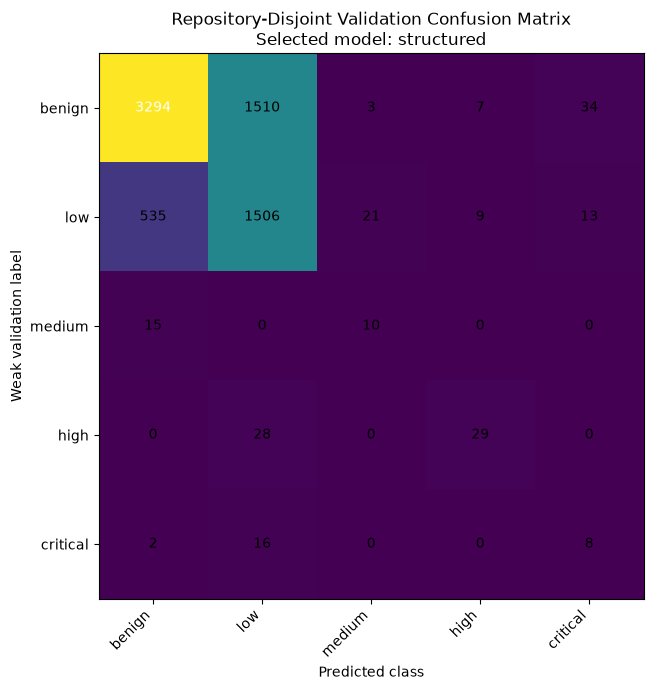

Saved: C:\Users\Lenovo\Desktop\DriftGuard\outputs\repository_disjoint_evaluation\figures\repository_validation_confusion_matrix.png


In [38]:
plt.figure(
    figsize=(9, 7)
)

plt.imshow(
    selected_confusion_matrix,
    interpolation="nearest",
)

plt.title(
    "Repository-Disjoint Validation Confusion Matrix\n"
    f"Selected model: {selected_primary_model_name}"
)

plt.xlabel("Predicted class")
plt.ylabel("Weak validation label")

plt.xticks(
    np.arange(
        len(CLASS_ORDER)
    ),
    CLASS_ORDER,
    rotation=45,
    ha="right",
)

plt.yticks(
    np.arange(
        len(CLASS_ORDER)
    ),
    CLASS_ORDER,
)

maximum_value = (
    selected_confusion_matrix.max()
    if selected_confusion_matrix.size
    else 0
)

text_threshold = (
    maximum_value / 2.0
)

for row_index in range(
    selected_confusion_matrix.shape[0]
):
    for column_index in range(
        selected_confusion_matrix.shape[1]
    ):
        value = (
            selected_confusion_matrix[
                row_index,
                column_index,
            ]
        )

        plt.text(
            column_index,
            row_index,
            str(value),
            ha="center",
            va="center",
            color=(
                "white"
                if value > text_threshold
                else "black"
            ),
        )

plt.tight_layout()

confusion_figure_path = (
    FIGURES_DIR
    / "repository_validation_confusion_matrix.png"
)

plt.savefig(
    confusion_figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    confusion_figure_path,
)

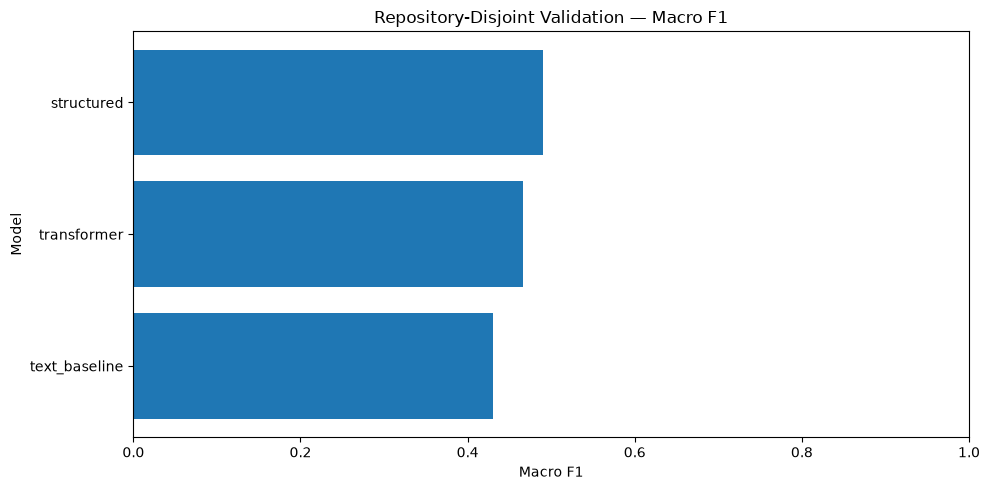

Saved: C:\Users\Lenovo\Desktop\DriftGuard\outputs\repository_disjoint_evaluation\figures\repository_validation_model_comparison.png


In [40]:
comparison_plot_data = (
    repository_validation_results
    .sort_values(
        "macro_f1",
        ascending=True,
    )
)

plt.figure(
    figsize=(10, 5)
)

plt.barh(
    comparison_plot_data[
        "model"
    ],
    comparison_plot_data[
        "macro_f1"
    ],
)

plt.title(
    "Repository-Disjoint Validation — Macro F1"
)

plt.xlabel("Macro F1")
plt.ylabel("Model")

plt.xlim(
    0,
    max(
        1.0,
        comparison_plot_data[
            "macro_f1"
        ].max() * 1.10,
    ),
)

plt.tight_layout()

comparison_figure_path = (
    FIGURES_DIR
    / "repository_validation_model_comparison.png"
)

plt.savefig(
    comparison_figure_path,
    dpi=150,
    bbox_inches="tight",
)

plt.show()

print(
    "Saved:",
    comparison_figure_path,
)

In [41]:
validation_prediction_output[
    "minimum_model_confidence"
] = validation_prediction_output[
    [
        "text_baseline_confidence",
        "structured_confidence",
        "transformer_confidence",
    ]
].min(
    axis=1
)

validation_prediction_output[
    "review_priority_score"
] = 0.0

validation_prediction_output.loc[
    validation_prediction_output[
        "evaluation_label"
    ].eq("critical")
    &
    validation_labeled_mask,
    "review_priority_score",
] += 100

validation_prediction_output.loc[
    selected_critical_false_negative_mask,
    "review_priority_score",
] += 100

validation_prediction_output.loc[
    selected_high_critical_false_negative_mask,
    "review_priority_score",
] += 75

validation_prediction_output.loc[
    validation_prediction_output[
        "three_way_disagreement"
    ],
    "review_priority_score",
] += 50

validation_prediction_output.loc[
    validation_prediction_output[
        "prediction_risk_spread"
    ] >= 2,
    "review_priority_score",
] += 35

validation_prediction_output[
    "review_priority_score"
] += (
    1.0
    - validation_prediction_output[
        "minimum_model_confidence"
    ].clip(
        lower=0.0,
        upper=1.0,
    )
) * 25.0

validation_review_queue = (
    validation_prediction_output
    .sort_values(
        [
            "review_priority_score",
            "prediction_risk_spread",
            "minimum_model_confidence",
        ],
        ascending=[
            False,
            False,
            True,
        ],
    )
    .head(
        REPOSITORY_EVALUATION_SETTINGS[
            "review_queue_size"
        ]
    )
    .copy()
)

validation_review_queue[
    "manual_label"
] = ""

validation_review_queue[
    "reviewer_notes"
] = ""

validation_review_queue[
    "review_status"
] = "pending"

print(
    "Manual-review queue records:",
    f"{len(validation_review_queue):,}",
)

display(
    validation_review_queue[
        [
            "review_priority_score",
            "repository",
            "configuration_type",
            "operation",
            "field_path",
            "old_value",
            "new_value",
            "evaluation_label",
            "text_baseline_prediction",
            "structured_prediction",
            "transformer_prediction",
            "prediction_risk_spread",
        ]
    ].head(25)
)

Manual-review queue records: 500


,review_priority_score,repository,configuration_type,operation,field_path,old_value,new_value,evaluation_label,text_baseline_prediction,structured_prediction,transformer_prediction,prediction_risk_spread
5001,375.955540,kubernetes_examples,yaml,added,$.parameters.restuserkey,NaN,password,critical,benign,low,critical,4
1081,326.542473,kubernetes_examples,yaml,added,$.parameters.user,NaN,root,critical,benign,benign,high,3
5590,326.387482,kubernetes_examples,yaml,modified,$.documents[2].spec.template.spec.containers[0...,password.txt,password,critical,low,low,critical,3
1587,326.038178,kubernetes_examples,yaml,modified,$.documents[2].spec.template.spec.containers[0...,password.txt,password,critical,low,low,critical,3
1082,324.463484,kubernetes_examples,yaml,added,$.parameters.restuser,NaN,admin,critical,benign,benign,high,3
34,322.673772,kubernetes_examples,json,added,$.extenders[0].enableHttps,NaN,false,critical,critical,low,low,3
237,322.276830,kubernetes_examples,json,added,$.extender.enableHttps,NaN,false,critical,critical,low,low,3
992,320.489444,kubernetes_examples,yaml,deleted,$.users[0].user.auth-path,/etc/secret-volume/kube-auth-path,NaN,critical,critical,low,critical,3
899,291.860425,kubernetes_examples,yaml,added,$.parameters.adminSecretNamespace,NaN,default,critical,low,low,low,0
3842,291.779102,kubernetes_examples,yaml,added,$.parameters.secretNamespace,NaN,default,critical,benign,low,low,1


In [42]:
primary_model_selection_manifest = {
    "selected_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),

    "selection_stage": (
        "repository_disjoint_validation"
    ),

    "selected_primary_model":
        selected_primary_model_name,

    "selection_metrics": (
        REPOSITORY_EVALUATION_SETTINGS[
            "selection_metrics"
        ]
    ),

    "selected_metrics": {
        key: (
            float(value)
            if isinstance(
                value,
                (
                    float,
                    np.floating,
                    int,
                    np.integer,
                ),
            )
            and not pd.isna(value)
            else None
        )
        for key, value
        in best_repository_validation_row.to_dict().items()
    },

    "training_repositories":
        sorted(
            training_repositories
        ),

    "validation_repositories":
        sorted(
            validation_repositories
        ),

    "validation_label_type":
        "weak_labels_review_only",

    "final_test_status":
        "sealed_not_loaded",

    "final_test_sha256":
        sealed_test_sha256,

    "selection_rule": (
        "Highest repository-disjoint macro F1; "
        "ties broken by critical recall, "
        "high/critical recall, macro PR-AUC, "
        "and balanced accuracy."
    ),

    "next_stage": (
        "Use all three model outputs in the "
        "hybrid deterministic-rule engine, "
        "while retaining the selected model "
        "as the primary learned classifier."
    ),
}

selection_manifest_path = (
    MANIFESTS_DIR
    / "primary_model_selection_manifest.json"
)

with selection_manifest_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        primary_model_selection_manifest,
        file,
        indent=2,
    )

print(
    "Primary model selection frozen:",
    selected_primary_model_name,
)

print(
    "Selection manifest:",
    selection_manifest_path,
)

Primary model selection frozen: structured
Selection manifest: C:\Users\Lenovo\Desktop\DriftGuard\outputs\repository_disjoint_evaluation\manifests\primary_model_selection_manifest.json


In [43]:
repository_results_path = (
    TABLES_DIR
    / "repository_validation_model_comparison.csv"
)

repository_validation_results.to_csv(
    repository_results_path,
    index=False,
)

per_class_metrics_path = (
    TABLES_DIR
    / "repository_validation_per_class_metrics.csv"
)

validation_per_class_metrics.to_csv(
    per_class_metrics_path,
    index=False,
)

repository_metrics_path = (
    TABLES_DIR
    / "repository_level_metrics.csv"
)

repository_metrics.to_csv(
    repository_metrics_path,
    index=False,
)

configuration_metrics_path = (
    TABLES_DIR
    / "configuration_type_metrics.csv"
)

configuration_type_metrics.to_csv(
    configuration_metrics_path,
    index=False,
)

agreement_summary_path = (
    TABLES_DIR
    / "model_agreement_summary.csv"
)

agreement_summary.to_csv(
    agreement_summary_path,
    index=False,
)

confusion_matrix_path = (
    TABLES_DIR
    / "selected_model_confusion_matrix.csv"
)

selected_confusion_matrix_df.to_csv(
    confusion_matrix_path
)

validation_predictions_path = (
    PREDICTIONS_DIR
    / "repository_validation_predictions.csv.gz"
)

validation_prediction_output.to_csv(
    validation_predictions_path,
    index=False,
    compression="gzip",
)

review_queue_path = (
    REVIEW_DIR
    / "repository_validation_review_queue.csv"
)

validation_review_queue.to_csv(
    review_queue_path,
    index=False,
)

critical_false_negative_path = (
    PREDICTIONS_DIR
    / "selected_model_critical_false_negatives.csv.gz"
)

selected_critical_false_negatives.to_csv(
    critical_false_negative_path,
    index=False,
    compression="gzip",
)

print("Saved model results :", repository_results_path)
print("Saved predictions   :", validation_predictions_path)
print("Saved review queue  :", review_queue_path)
print("Saved error records :", critical_false_negative_path)

Saved model results : C:\Users\Lenovo\Desktop\DriftGuard\outputs\repository_disjoint_evaluation\tables\repository_validation_model_comparison.csv
Saved predictions   : C:\Users\Lenovo\Desktop\DriftGuard\outputs\repository_disjoint_evaluation\predictions\repository_validation_predictions.csv.gz
Saved review queue  : C:\Users\Lenovo\Desktop\DriftGuard\outputs\repository_disjoint_evaluation\manual_review\repository_validation_review_queue.csv
Saved error records : C:\Users\Lenovo\Desktop\DriftGuard\outputs\repository_disjoint_evaluation\predictions\selected_model_critical_false_negatives.csv.gz


In [45]:
print("=" * 72)
print("NORMALIZING MODEL PROBABILITY MATRICES")
print("=" * 72)

for model_name, model_output in validation_model_outputs.items():
    probabilities = np.asarray(
        model_output["probability_matrix"],
        dtype=np.float64,
    )

    print(f"\nModel: {model_name}")
    print("Shape:", probabilities.shape)
    print("NaN values:", int(np.isnan(probabilities).sum()))
    print("Infinite values:", int(np.isinf(probabilities).sum()))

    if not np.isfinite(probabilities).all():
        raise ValueError(
            f"{model_name} contains non-finite probability values."
        )

    # Remove extremely small negative values caused by numerical precision.
    probabilities = np.clip(
        probabilities,
        0.0,
        None,
    )

    row_sums_before = probabilities.sum(axis=1)

    print(
        "Row-sum range before:",
        f"{row_sums_before.min():.10f}",
        "to",
        f"{row_sums_before.max():.10f}",
    )

    zero_sum_rows = row_sums_before <= 0

    if zero_sum_rows.any():
        print(
            "Zero-sum rows repaired:",
            int(zero_sum_rows.sum()),
        )

        probabilities[
            zero_sum_rows
        ] = 1.0 / len(CLASS_ORDER)

    probabilities = (
        probabilities
        / probabilities.sum(
            axis=1,
            keepdims=True,
        )
    )

    model_output[
        "probability_matrix"
    ] = probabilities

    # For probability-based models, the score matrix should be identical.
    if model_output["probability_kind"] == "probability":
        model_output[
            "score_matrix"
        ] = probabilities.copy()

    row_sums_after = probabilities.sum(axis=1)

    print(
        "Row-sum range after :",
        f"{row_sums_after.min():.10f}",
        "to",
        f"{row_sums_after.max():.10f}",
    )

    print(
        "Rows summing to one :",
        np.allclose(
            row_sums_after,
            1.0,
            atol=1e-8,
        ),
    )

print("\nProbability normalization completed.")

NORMALIZING MODEL PROBABILITY MATRICES

Model: text_baseline
Shape: (7628, 5)
NaN values: 0
Infinite values: 0
Row-sum range before: 1.0000000000 to 1.0000000000
Row-sum range after : 1.0000000000 to 1.0000000000
Rows summing to one : True

Model: structured
Shape: (7628, 5)
NaN values: 0
Infinite values: 0
Row-sum range before: 1.0000000000 to 1.0000000000
Row-sum range after : 1.0000000000 to 1.0000000000
Rows summing to one : True

Model: transformer
Shape: (7628, 5)
NaN values: 0
Infinite values: 0
Row-sum range before: 0.9996799827 to 1.0003209114
Row-sum range after : 1.0000000000 to 1.0000000000
Rows summing to one : True

Probability normalization completed.


In [46]:
repository_evaluation_integrity_checks = {
    "Validation data is not empty":
        len(
            validation_data
        ) > 0,

    "Validation contains labeled records":
        len(
            validation_labeled_data
        ) > 0,

    "Training and validation repositories are disjoint":
        len(
            repository_overlap
        ) == 0,

    "Training and validation commits are disjoint":
        len(
            commit_overlap
        ) == 0,

    "Change signatures are disjoint":
        (
            signature_overlap_count is None
            or signature_overlap_count == 0
        ),

    "All three models produced predictions":
        set(
            validation_model_outputs.keys()
        )
        == {
            "text_baseline",
            "structured",
            "transformer",
        },

    "All prediction counts match validation records":
        all(
            len(
                model_output[
                    "predicted_labels"
                ]
            )
            == len(
                validation_data
            )
            for model_output
            in validation_model_outputs.values()
        ),

    "All predicted labels are valid":
        all(
            np.isin(
                model_output[
                    "predicted_labels"
                ],
                CLASS_ORDER,
            ).all()
            for model_output
            in validation_model_outputs.values()
        ),

    "Probability rows sum to one":
        all(
            np.allclose(
                model_output[
                    "probability_matrix"
                ].sum(
                    axis=1
                ),
                1.0,
                atol=1e-5,
            )
            for model_output
            in validation_model_outputs.values()
        ),

    "Primary model was selected":
        selected_primary_model_name
        in validation_model_outputs,

    "Final test file was not loaded":
        sealed_test_manifest[
            "status"
        ]
        == "SEALED_NOT_LOADED",

    "Final test SHA-256 exists":
        len(
            sealed_test_sha256
        )
        == 64,

    "Selection manifest exists":
        selection_manifest_path.exists(),

    "Results file exists":
        repository_results_path.exists(),

    "Prediction output exists":
        validation_predictions_path.exists(),

    "Review queue exists":
        review_queue_path.exists(),
}

print(
    "Repository-disjoint integrity checks:\n"
)

for check_name, passed in (
    repository_evaluation_integrity_checks.items()
):
    print(
        f"{'PASSED' if passed else 'FAILED':<8}"
        f" | {check_name}"
    )

failed_repository_checks = [
    check_name
    for check_name, passed
    in repository_evaluation_integrity_checks.items()
    if not bool(passed)
]

print(
    "\nFailed integrity checks:",
    len(
        failed_repository_checks
    ),
)

Repository-disjoint integrity checks:

PASSED   | Validation data is not empty
PASSED   | Validation contains labeled records
PASSED   | Training and validation repositories are disjoint
PASSED   | Training and validation commits are disjoint
PASSED   | Change signatures are disjoint
PASSED   | All three models produced predictions
PASSED   | All prediction counts match validation records
PASSED   | All predicted labels are valid
PASSED   | Probability rows sum to one
PASSED   | Primary model was selected
PASSED   | Final test file was not loaded
PASSED   | Final test SHA-256 exists
PASSED   | Selection manifest exists
PASSED   | Results file exists
PASSED   | Prediction output exists
PASSED   | Review queue exists

Failed integrity checks: 0


In [47]:
def convert_json_safe_value(
    value,
):
    if isinstance(
        value,
        (
            np.integer,
            int,
        ),
    ):
        return int(value)

    if isinstance(
        value,
        (
            np.floating,
            float,
        ),
    ):
        if pd.isna(value):
            return None

        return float(value)

    if isinstance(
        value,
        np.bool_,
    ):
        return bool(value)

    return value


repository_evaluation_summary = {
    "generated_at_utc": datetime.now(
        timezone.utc
    ).isoformat(),

    "validation_file":
        str(
            validation_data_path
        ),

    "validation_total_records":
        int(
            len(
                validation_data
            )
        ),

    "validation_labeled_records":
        int(
            len(
                validation_labeled_data
            )
        ),

    "validation_label_column":
        validation_label_column,

    "training_repositories":
        sorted(
            training_repositories
        ),

    "validation_repositories":
        sorted(
            validation_repositories
        ),

    "repository_overlap":
        int(
            len(
                repository_overlap
            )
        ),

    "commit_overlap":
        int(
            len(
                commit_overlap
            )
        ),

    "signature_overlap":
        signature_overlap_count,

    "model_results": [
        {
            key: convert_json_safe_value(
                value
            )
            for key, value
            in record.items()
        }
        for record in (
            repository_validation_results
            .to_dict(
                orient="records"
            )
        )
    ],

    "selected_primary_model":
        selected_primary_model_name,

    "selected_critical_false_negatives":
        int(
            len(
                selected_critical_false_negatives
            )
        ),

    "selected_high_critical_false_negatives":
        int(
            len(
                selected_high_critical_false_negatives
            )
        ),

    "selected_high_critical_false_positives":
        int(
            len(
                selected_high_critical_false_positives
            )
        ),

    "manual_review_queue_records":
        int(
            len(
                validation_review_queue
            )
        ),

    "sealed_final_test": {
        "path":
            str(
                sealed_test_data_path
            ),

        "sha256":
            sealed_test_sha256,

        "status":
            "SEALED_NOT_LOADED",
    },

    "failed_integrity_checks":
        failed_repository_checks,

    "all_integrity_checks_passed":
        len(
            failed_repository_checks
        ) == 0,
}

repository_summary_path = (
    OUTPUTS_DIR
    / "repository_disjoint_evaluation_summary.json"
)

with repository_summary_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        repository_evaluation_summary,
        file,
        indent=2,
    )

print(
    "Saved evaluation summary:",
    repository_summary_path,
)

Saved evaluation summary: C:\Users\Lenovo\Desktop\DriftGuard\outputs\repository_disjoint_evaluation\repository_disjoint_evaluation_summary.json


In [48]:
print("=" * 72)
print("NOTEBOOK 10 — REQUIRED RESULTS")
print("=" * 72)

print("\n1. REPOSITORY-DISJOINT DATASET")
print("-" * 72)

print(
    "Validation file          :",
    validation_data_path.name,
)

print(
    "Validation total records :",
    f"{len(validation_data):,}",
)

print(
    "Validation labeled       :",
    f"{len(validation_labeled_data):,}",
)

print(
    "Validation unlabeled     :",
    f"{(~validation_labeled_mask).sum():,}",
)

print(
    "Training repositories    :",
    sorted(
        training_repositories
    ),
)

print(
    "Validation repositories  :",
    sorted(
        validation_repositories
    ),
)

print(
    "Repository overlap       :",
    len(
        repository_overlap
    ),
)

print(
    "Commit overlap           :",
    len(
        commit_overlap
    ),
)

print(
    "Signature overlap        :",
    signature_overlap_count,
)

print("\n2. REPOSITORY-DISJOINT MODEL RANKING")
print("-" * 72)

display(
    repository_validation_results[
        [
            "rank",
            "model",
            "accuracy",
            "balanced_accuracy",
            "macro_f1",
            "weighted_f1",
            "macro_pr_auc",
            "log_loss",
            "critical_precision",
            "critical_recall",
            "critical_f1",
            "high_critical_precision",
            "high_critical_recall",
            "high_critical_f1",
            "inference_seconds",
        ]
    ]
)

print("\n3. SELECTED PRIMARY MODEL")
print("-" * 72)

print(
    "Selected model           :",
    selected_primary_model_name,
)

print(
    "Macro F1                 :",
    f"{best_repository_validation_row['macro_f1']:.4f}",
)

print(
    "Balanced accuracy        :",
    f"{best_repository_validation_row['balanced_accuracy']:.4f}",
)

print(
    "Macro PR-AUC             :",
    f"{best_repository_validation_row['macro_pr_auc']:.4f}",
)

print(
    "Critical precision       :",
    f"{best_repository_validation_row['critical_precision']:.4f}",
)

print(
    "Critical recall          :",
    f"{best_repository_validation_row['critical_recall']:.4f}",
)

print(
    "High/critical precision  :",
    f"{best_repository_validation_row['high_critical_precision']:.4f}",
)

print(
    "High/critical recall     :",
    f"{best_repository_validation_row['high_critical_recall']:.4f}",
)

print("\n4. SELECTED-MODEL PER-CLASS RESULTS")
print("-" * 72)

display(
    selected_validation_per_class
)

print("\n5. SAFETY-CRITICAL ERRORS")
print("-" * 72)

print(
    "Critical false negatives     :",
    f"{len(selected_critical_false_negatives):,}",
)

print(
    "High/critical false negatives:",
    f"{len(selected_high_critical_false_negatives):,}",
)

print(
    "High/critical false positives:",
    f"{len(selected_high_critical_false_positives):,}",
)

print("\n6. MODEL AGREEMENT")
print("-" * 72)

display(
    agreement_summary
)

print("\n7. MANUAL-REVIEW QUEUE")
print("-" * 72)

print(
    "Prioritized review records:",
    f"{len(validation_review_queue):,}",
)

print(
    "Review queue path:",
    review_queue_path,
)

print("\n8. SEALED FINAL TEST")
print("-" * 72)

print(
    "Status :",
    sealed_test_manifest[
        "status"
    ],
)

print(
    "File   :",
    sealed_test_data_path.name,
)

print(
    "SHA-256:",
    sealed_test_sha256,
)

print(
    "The final test file was not loaded or evaluated."
)

print("\n9. FAILED INTEGRITY CHECKS")
print("-" * 72)

if failed_repository_checks:
    for index, check_name in enumerate(
        failed_repository_checks,
        start=1,
    ):
        print(
            f"{index}. {check_name}"
        )
else:
    print(
        "No failed integrity checks."
    )

    print(
        "All repository-disjoint integrity checks passed."
    )

print("\n" + "=" * 72)
print("REQUIRED RESULTS GENERATED")
print("=" * 72)

NOTEBOOK 10 — REQUIRED RESULTS

1. REPOSITORY-DISJOINT DATASET
------------------------------------------------------------------------
Validation file          : validation_review_only.csv.gz
Validation total records : 7,628
Validation labeled       : 7,040
Validation unlabeled     : 588
Training repositories    : ['kube_prometheus', 'microservices_demo', 'terraform_aws_vpc']
Validation repositories  : ['kubernetes_examples']
Repository overlap       : 0
Commit overlap           : 0
Signature overlap        : 0

2. REPOSITORY-DISJOINT MODEL RANKING
------------------------------------------------------------------------


,rank,model,accuracy,balanced_accuracy,macro_f1,weighted_f1,macro_pr_auc,log_loss,critical_precision,critical_recall,critical_f1,high_critical_precision,high_critical_recall,high_critical_f1,inference_seconds
0,1,structured,0.688494,0.523714,0.489688,0.701693,0.514054,4.175535,0.145455,0.307692,0.197531,0.370000,0.445783,0.404372,1.901652
1,2,transformer,0.735369,0.665565,0.466340,0.754350,0.495934,3.021484,0.142857,0.269231,0.186667,0.141509,0.542169,0.224439,28.406632
2,3,text_baseline,0.739205,0.623683,0.430913,0.762901,0.555131,NaN,0.193548,0.230769,0.210526,0.103343,0.409639,0.165049,14.888286



3. SELECTED PRIMARY MODEL
------------------------------------------------------------------------
Selected model           : structured
Macro F1                 : 0.4897
Balanced accuracy        : 0.5237
Macro PR-AUC             : 0.5141
Critical precision       : 0.1455
Critical recall          : 0.3077
High/critical precision  : 0.3700
High/critical recall     : 0.4458

4. SELECTED-MODEL PER-CLASS RESULTS
------------------------------------------------------------------------


,model,class,support,precision,recall,f1,average_precision
5,structured,benign,4848,0.856474,0.679455,0.757764,0.881526
6,structured,low,2084,0.492157,0.722649,0.585537,0.647837
7,structured,medium,25,0.294118,0.400000,0.338983,0.351126
8,structured,high,57,0.644444,0.508772,0.568627,0.530129
9,structured,critical,26,0.145455,0.307692,0.197531,0.159652



5. SAFETY-CRITICAL ERRORS
------------------------------------------------------------------------
Critical false negatives     : 18
High/critical false negatives: 46
High/critical false positives: 63

6. MODEL AGREEMENT
------------------------------------------------------------------------


,agreement_type,records
0,unanimous,4542
1,two_or_more_labels,3086
2,three_way_disagreement,396
3,risk_spread_two_or_more,995



7. MANUAL-REVIEW QUEUE
------------------------------------------------------------------------
Prioritized review records: 500
Review queue path: C:\Users\Lenovo\Desktop\DriftGuard\outputs\repository_disjoint_evaluation\manual_review\repository_validation_review_queue.csv

8. SEALED FINAL TEST
------------------------------------------------------------------------
Status : SEALED_NOT_LOADED
File   : test_final_evaluation_only.csv.gz
SHA-256: cff0f85db740a195366fb81cbad26ba34859f40fe12bf8695b263d1cdedb9b67
The final test file was not loaded or evaluated.

9. FAILED INTEGRITY CHECKS
------------------------------------------------------------------------
No failed integrity checks.
All repository-disjoint integrity checks passed.

REQUIRED RESULTS GENERATED


In [49]:
print("=" * 72)
print("NOTEBOOK 10 COMPLETED")
print("=" * 72)

print(
    "Repository-disjoint validation repository:",
    sorted(
        validation_repositories
    ),
)

print(
    "Validation labeled records:",
    f"{len(validation_labeled_data):,}",
)

print(
    "Selected primary model:",
    selected_primary_model_name,
)

print(
    "Repository-disjoint macro F1:",
    f"{best_repository_validation_row['macro_f1']:.4f}",
)

print(
    "Repository-disjoint critical recall:",
    f"{best_repository_validation_row['critical_recall']:.4f}",
)

print(
    "Repository-disjoint high/critical recall:",
    f"{best_repository_validation_row['high_critical_recall']:.4f}",
)

print(
    "Critical false negatives:",
    f"{len(selected_critical_false_negatives):,}",
)

print(
    "Manual-review queue:",
    review_queue_path,
)

print(
    "Final test status:",
    sealed_test_manifest[
        "status"
    ],
)

print(
    "Selection manifest:",
    selection_manifest_path,
)

print("\nImportant:")
print("- Validation is repository-disjoint from all model-training repositories.")
print("- Validation metrics still use weak labels, not verified ground truth.")
print("- All three model families remain available to the hybrid engine.")
print("- The selected model becomes the primary learned classifier.")
print("- Deterministic rules may override unsafe learned predictions.")
print("- The final test remains sealed until the complete system is frozen.")

print("\nNext notebook:")
print("11_hybrid_rules_model_engine.ipynb")

NOTEBOOK 10 COMPLETED
Repository-disjoint validation repository: ['kubernetes_examples']
Validation labeled records: 7,040
Selected primary model: structured
Repository-disjoint macro F1: 0.4897
Repository-disjoint critical recall: 0.3077
Repository-disjoint high/critical recall: 0.4458
Critical false negatives: 18
Manual-review queue: C:\Users\Lenovo\Desktop\DriftGuard\outputs\repository_disjoint_evaluation\manual_review\repository_validation_review_queue.csv
Final test status: SEALED_NOT_LOADED
Selection manifest: C:\Users\Lenovo\Desktop\DriftGuard\outputs\repository_disjoint_evaluation\manifests\primary_model_selection_manifest.json

Important:
- Validation is repository-disjoint from all model-training repositories.
- Validation metrics still use weak labels, not verified ground truth.
- All three model families remain available to the hybrid engine.
- The selected model becomes the primary learned classifier.
- Deterministic rules may override unsafe learned predictions.
- The fin